# India Groundwater Crisis — Early Warning System
## Hybrid ML Pipeline: Isolation Forest + XGBoost + Forecasting + SHAP
**Data:** India WRIS (Govt. of India) | 6,340 stations | 1994–2025  
**Pipeline:** Anomaly Detection → Crisis Classification → Multi-Year Forecasting  → SHAP

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import subprocess, sys
for pkg in ['xgboost','shap','statsmodels']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg])

import xgboost as xgb, shap
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              precision_recall_fscore_support,
                              mean_squared_error, mean_absolute_error, r2_score)
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('Groundwater India Data.csv')
df.columns = df.columns.str.strip()
if 't  kmnpnn]2m' in df.columns:
    df.rename(columns={'t  kmnpnn]2m': 't2m_ambient'}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['station_id','datetime']).reset_index(drop=True)
df = df[(df['target'] >= -50) & (df['target'] <= 50)].copy()
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

print(f"Rows         : {len(df):,}")
print(f"Stations     : {df['station_id'].nunique():,}")
print(f"Date range   : {df['year'].min()} – {df['year'].max()}")
print(f"Missing vals : {df.isnull().sum().sum()}")
df.head()

Rows         : 406,783
Stations     : 6,340
Date range   : 1994 – 2025
Missing vals : 0


,time_idx,station_id,datetime,target,rainfall,t2m_ambient,t2m_max,t2m_min,month,latitude,longitude,wellDepth,wellAquiferType_encoded,State_encoded,District_encoded,year
0,0,081455077183001,2013-01-05,7.67,0.00,27.40,29.58,26.03,1,8.2486,77.3083,31.45,1,1,1,2013
1,1,081455077183001,2013-08-25,7.80,0.02,26.53,28.14,25.29,8,8.2486,77.3083,31.45,1,1,1,2013
2,2,081455077183001,2013-11-05,7.86,8.15,27.39,28.62,26.24,11,8.2486,77.3083,31.45,1,1,1,2013
3,3,081455077183001,2014-01-05,7.84,0.00,26.92,30.61,23.76,1,8.2486,77.3083,31.45,1,1,1,2014
4,4,081455077183001,2014-05-15,7.65,0.02,29.37,30.73,28.34,5,8.2486,77.3083,31.45,1,1,1,2014


## Feature Engineering

In [6]:
def compute_slope(series):
    """Linear depletion rate over full history (m per reading)"""
    if len(series) < 2: return 0
    return np.polyfit(np.arange(len(series)), series, 1)[0]

station_slope = (df.groupby('station_id')['target']
                   .apply(compute_slope).reset_index()
                   .rename(columns={'target':'depletion_slope'}))
df = df.merge(station_slope, on='station_id', how='left')

station = df.groupby('station_id').agg(
    latitude                = ('latitude','first'),
    longitude               = ('longitude','first'),
    wellDepth               = ('wellDepth','first'),
    wellAquiferType_encoded = ('wellAquiferType_encoded','first'),
    avg_rainfall            = ('rainfall','mean'),
    std_rainfall            = ('rainfall','std'),
    avg_t2m                 = ('t2m_ambient','mean'),
    avg_target              = ('target','mean'),
    min_target              = ('target','min'),
    max_target              = ('target','max'),
    target_range            = ('target', lambda x: x.max()-x.min()),
    depletion_slope         = ('depletion_slope','first'),
).reset_index()

# Label based on slope — Safe/Stressed/Critical
def label_station(s):
    if s >= -0.01:   return 0  # Safe
    elif s >= -0.05: return 1  # Stressed
    else:            return 2  # Critical

station['label'] = station['depletion_slope'].apply(label_station)
counts = station['label'].value_counts().sort_index()
print(f"Safe     : {counts[0]:,} ({counts[0]/len(station)*100:.1f}%)")
print(f"Stressed : {counts[1]:,} ({counts[1]/len(station)*100:.1f}%)")
print(f"Critical : {counts[2]:,} ({counts[2]/len(station)*100:.1f}%)")

Safe     : 3,906 (61.6%)
Stressed : 1,197 (18.9%)
Critical : 1,237 (19.5%)


## Isolation Forest (Anomaly Detection)

In [7]:
ISO_FEAT = ['avg_rainfall','std_rainfall','avg_t2m','wellDepth',
            'wellAquiferType_encoded','latitude','longitude',
            'avg_target','min_target','max_target','target_range']

iso = IsolationForest(contamination=0.15, n_estimators=200, random_state=42)
station['is_anomaly'] = (iso.fit_predict(station[ISO_FEAT]) == -1).astype(int)

n_anom = station['is_anomaly'].sum()
print(f"Anomalous stations : {n_anom} ({n_anom/len(station)*100:.1f}%)")
print(f"Normal stations    : {len(station)-n_anom}")
print()
print("Mean features — Normal vs Anomalous:")
print(station.groupby('is_anomaly')[
    ['avg_rainfall','avg_target','wellDepth','depletion_slope']].mean().round(3))

Anomalous stations : 951 (15.0%)
Normal stations    : 5389

Mean features — Normal vs Anomalous:
            avg_rainfall  avg_target  wellDepth  depletion_slope
is_anomaly                                                      
0                  2.394       5.570     27.052           -0.083
1                  3.356       4.135    110.211           -0.067


## India Groundwater Crisis Map

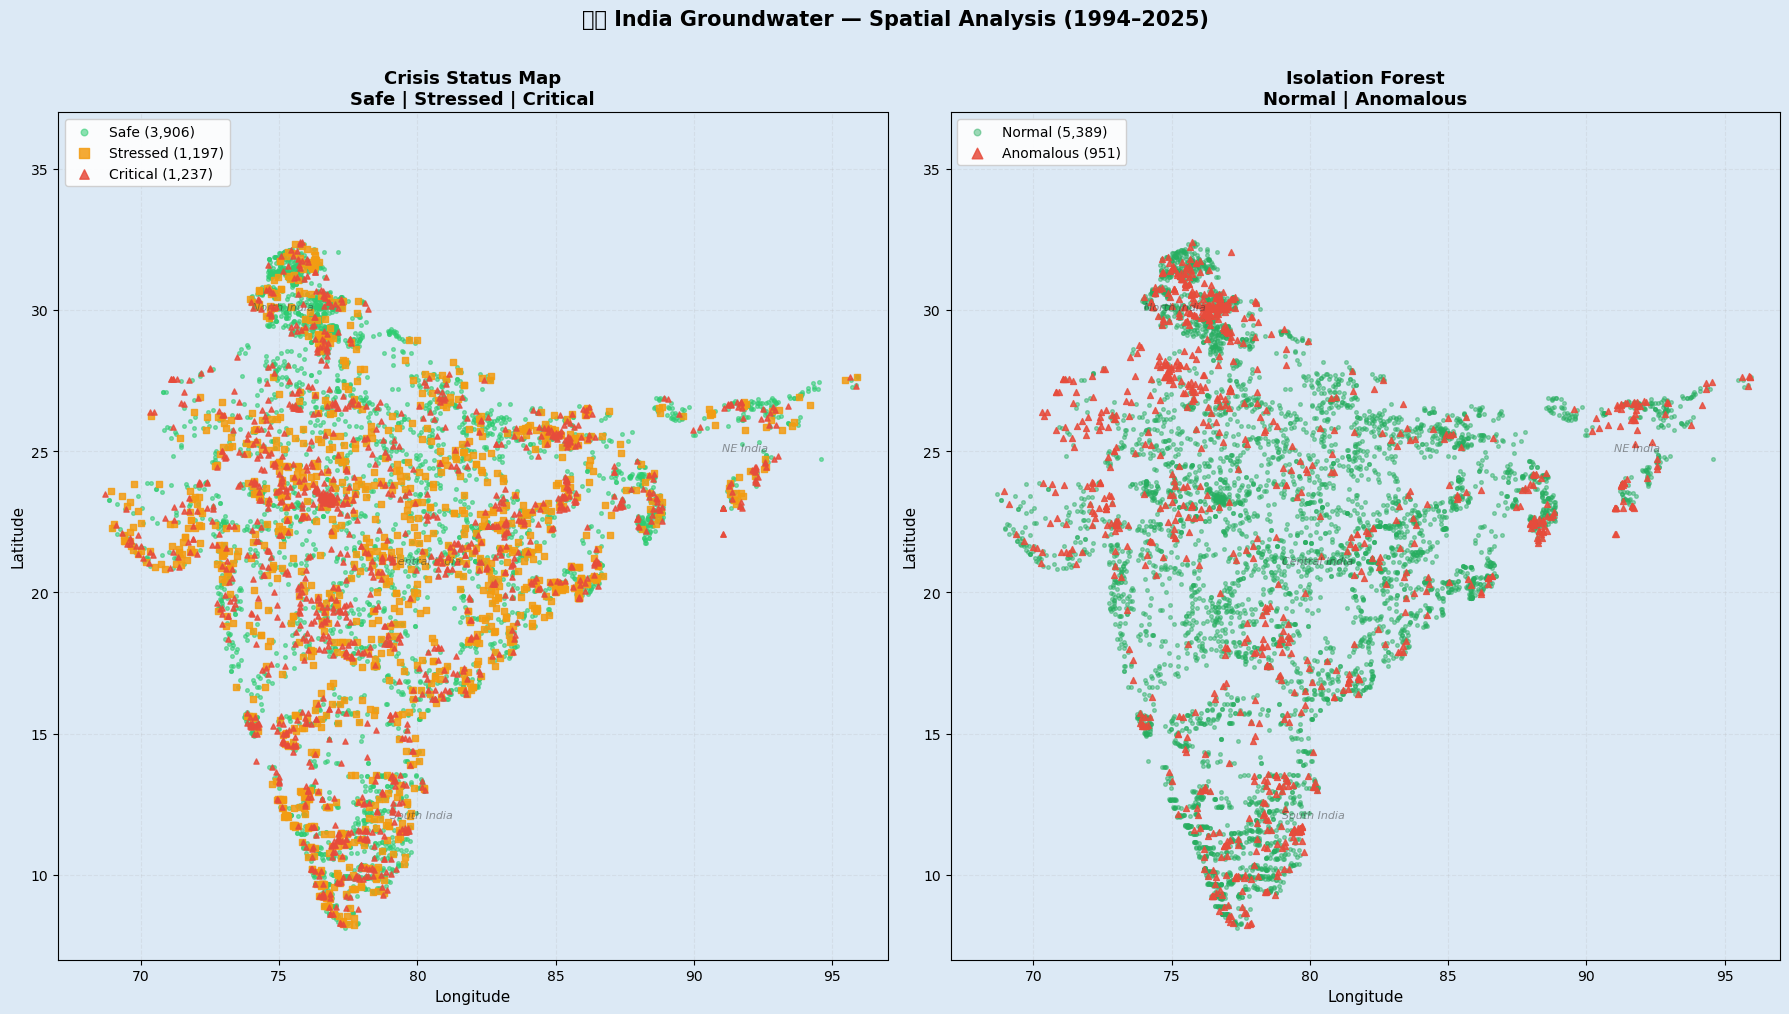

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#dce9f5')
lc={0:'#2ecc71',1:'#f39c12',2:'#e74c3c'}
ln={0:'Safe',1:'Stressed',2:'Critical'}
ls={0:7,1:14,2:14}; lm={0:'o',1:'s',2:'^'}

for ax,(col,title) in zip(axes,[
    ('label','Crisis Status Map\nSafe | Stressed | Critical'),
    ('is_anomaly','Isolation Forest\nNormal | Anomalous')]):
    ax.set_facecolor('#dce9f5')
    if col=='label':
        for lbl in [0,1,2]:
            sub=station[station['label']==lbl]
            ax.scatter(sub['longitude'],sub['latitude'],c=lc[lbl],s=ls[lbl],
                       alpha=0.55 if lbl==0 else 0.85,
                       label=f"{ln[lbl]} ({len(sub):,})",marker=lm[lbl],zorder=lbl+2)
    else:
        for flag,clr,lbl_,mk in [(0,'#27ae60','Normal','o'),(1,'#e74c3c','Anomalous','^')]:
            sub=station[station['is_anomaly']==flag]
            ax.scatter(sub['longitude'],sub['latitude'],c=clr,
                       s=7 if flag==0 else 18,alpha=0.45 if flag==0 else 0.85,
                       label=f"{lbl_} ({len(sub):,})",marker=mk,zorder=flag+2)
    ax.set_xlim(67,97); ax.set_ylim(7,37)
    ax.set_xlabel('Longitude',fontsize=11); ax.set_ylabel('Latitude',fontsize=11)
    ax.set_title(title,fontsize=13,fontweight='bold')
    ax.legend(fontsize=10,markerscale=1.8,loc='upper left',framealpha=0.9)
    ax.grid(True,alpha=0.2,linestyle='--')
    for txt,(lon,lat) in [('North India',(74,30)),('Central India',(79,21)),
                           ('South India',(79,12)),('NE India',(91,25))]:
        ax.text(lon,lat,txt,fontsize=8,color='#333',alpha=0.5,style='italic')
plt.suptitle('🇮🇳 India Groundwater — Spatial Analysis (1994–2025)',
             fontsize=15,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## XGBoost vs Random Forest Classification

XGBoost  : 62.22%
RF       : 49.84%  (baseline)
Δ        : +12.38%

              precision    recall  f1-score   support

        Safe       0.78      0.70      0.74       781
    Stressed       0.39      0.50      0.44       240
    Critical       0.47      0.51      0.49       247

    accuracy                           0.62      1268
   macro avg       0.55      0.57      0.55      1268
weighted avg       0.65      0.62      0.63      1268

Note: class-balanced weighting trades a bit of overall accuracy for much
better recall on Stressed/Critical — the classes that actually matter.


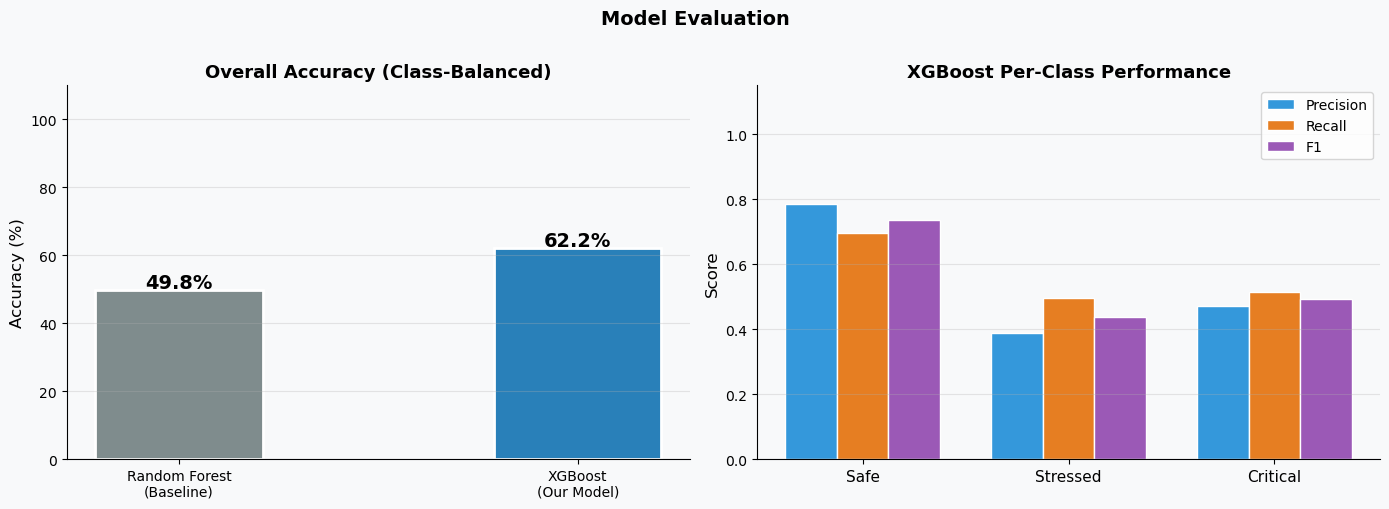

In [9]:
FEAT = ISO_FEAT + ['is_anomaly']
FEAT_LABELS = ['Avg Rainfall','Rainfall Variability','Avg Temp','Well Depth',
               'Aquifer Type','Latitude','Longitude','Avg GW Level',
               'Min GW Level','Max GW Level','GW Range','Anomaly Flag (IF)']

X = station[FEAT]; y = station['label']
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# ── Fix class imbalance: Stressed (19%) and Critical (20%) were being
# drowned out by Safe (61%). Compute per-sample weights so XGBoost
# penalizes mistakes on minority classes more heavily.
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

xgb_model = xgb.XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                                subsample=0.8,colsample_bytree=0.8,
                                eval_metric='mlogloss',random_state=42)
xgb_model.fit(X_tr,y_tr,sample_weight=sample_weights)
xgb_pred = xgb_model.predict(X_te)
xgb_acc  = accuracy_score(y_te,xgb_pred)

# Random Forest baseline — also balanced for fair comparison
rf_model = RandomForestClassifier(n_estimators=200,max_depth=8,
                                    class_weight='balanced',random_state=42)
rf_model.fit(X_tr,y_tr); rf_pred=rf_model.predict(X_te); rf_acc=accuracy_score(y_te,rf_pred)

print(f"XGBoost  : {xgb_acc*100:.2f}%")
print(f"RF       : {rf_acc*100:.2f}%  (baseline)")
print(f"Δ        : {(xgb_acc-rf_acc)*100:+.2f}%")
print(); print(classification_report(y_te,xgb_pred,target_names=['Safe','Stressed','Critical']))
print("Note: class-balanced weighting trades a bit of overall accuracy for much")
print("better recall on Stressed/Critical — the classes that actually matter.")

fig,axes=plt.subplots(1,2,figsize=(14,5)); fig.patch.set_facecolor('#f8f9fa')
ax=axes[0]; ax.set_facecolor('#f8f9fa')
bars=ax.bar(['Random Forest\n(Baseline)','XGBoost\n(Our Model)'],
            [rf_acc*100,xgb_acc*100],color=['#7f8c8d','#2980b9'],width=0.42,edgecolor='white',linewidth=2)
for bar,acc in zip(bars,[rf_acc*100,xgb_acc*100]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,
            f'{acc:.1f}%',ha='center',fontsize=14,fontweight='bold')
ax.set_ylim(0,110); ax.set_ylabel('Accuracy (%)',fontsize=12)
ax.set_title('Overall Accuracy (Class-Balanced)',fontsize=13,fontweight='bold')
ax.grid(axis='y',alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2=axes[1]; ax2.set_facecolor('#f8f9fa')
p,r,f1,_=precision_recall_fscore_support(y_te,xgb_pred,labels=[0,1,2])
x=np.arange(3); w=0.25
ax2.bar(x-w,p,w,label='Precision',color='#3498db',edgecolor='white')
ax2.bar(x,r,w,label='Recall',color='#e67e22',edgecolor='white')
ax2.bar(x+w,f1,w,label='F1',color='#9b59b6',edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(['Safe','Stressed','Critical'],fontsize=11)
ax2.set_ylim(0,1.15); ax2.set_ylabel('Score',fontsize=12)
ax2.set_title('XGBoost Per-Class Performance',fontsize=13,fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(axis='y',alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.suptitle('Model Evaluation',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## SHAP Explainability

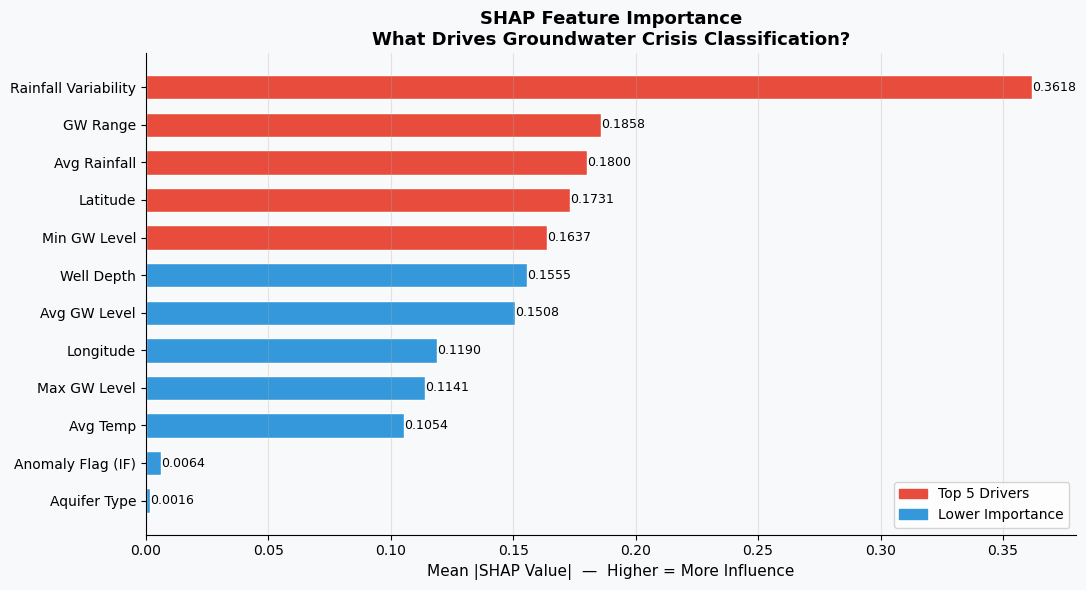

Top 5 crisis drivers:
  Rainfall Variability          : 0.3618
  GW Range                      : 0.1858
  Avg Rainfall                  : 0.1800
  Latitude                      : 0.1731
  Min GW Level                  : 0.1637


In [10]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_te)
mean_shap   = np.mean([np.abs(shap_values[:,:,i]) for i in range(3)],axis=0).mean(axis=0)
sorted_idx  = np.argsort(mean_shap); top5=set(sorted_idx[-5:])

fig,ax=plt.subplots(figsize=(11,6)); fig.patch.set_facecolor('#f8f9fa'); ax.set_facecolor('#f8f9fa')
palette=['#e74c3c' if i in top5 else '#3498db' for i in sorted_idx]
bars=ax.barh([FEAT_LABELS[i] for i in sorted_idx],mean_shap[sorted_idx],
             color=palette,edgecolor='white',height=0.65)
for bar,val in zip(bars,mean_shap[sorted_idx]):
    ax.text(bar.get_width()+0.0001,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=9)
ax.set_xlabel('Mean |SHAP Value|  —  Higher = More Influence',fontsize=11)
ax.set_title('SHAP Feature Importance\nWhat Drives Groundwater Crisis Classification?',
             fontsize=13,fontweight='bold')
ax.grid(axis='x',alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(handles=[mpatches.Patch(color='#e74c3c',label='Top 5 Drivers'),
                   mpatches.Patch(color='#3498db',label='Lower Importance')],fontsize=10,loc='lower right')
plt.tight_layout(); plt.show()
print("Top 5 crisis drivers:")
for i in sorted_idx[-5:][::-1]:
    print(f"  {FEAT_LABELS[i]:30s}: {mean_shap[i]:.4f}")

## Multi-Year Forecasting

In [11]:
# Only keep stations with ≥20 readings for reliable lag features
good_sids = df.groupby('station_id').size()
good_sids = good_sids[good_sids >= 20].index
df_g = df[df['station_id'].isin(good_sids)].copy()

for lag in [1,2,3]:
    df_g[f'lag_{lag}'] = df_g.groupby('station_id')['target'].shift(lag)
df_g['roll_3'] = df_g.groupby('station_id')['target'].transform(
    lambda x: x.rolling(3,min_periods=1).mean())
df_g['roll_6'] = df_g.groupby('station_id')['target'].transform(
    lambda x: x.rolling(6,min_periods=1).mean())

FORE_FEAT = ['lag_1','lag_2','lag_3','roll_3','roll_6','rainfall','t2m_ambient','month']

def train_forecast_model(df_g, horizon_shift, horizon_label):
    df_f = df_g.copy()
    df_f['future_target'] = df_f.groupby('station_id')['target'].shift(-horizon_shift)
    df_f = df_f.dropna(subset=['lag_1','lag_2','lag_3','future_target'])
    df_f = df_f.sort_values(['station_id','datetime'])

    split = int(len(df_f) * 0.8)
    X_tr, X_te = df_f[FORE_FEAT].iloc[:split], df_f[FORE_FEAT].iloc[split:]
    y_tr, y_te = df_f['future_target'].iloc[:split], df_f['future_target'].iloc[split:]

    model = xgb.XGBRegressor(n_estimators=200,max_depth=5,learning_rate=0.05,random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    print(f"  {horizon_label}: RMSE={rmse:.3f}m  MAE={mae:.3f}m  R²={r2:.3f}")
    return model, rmse, mae, r2, y_te, y_pred

print("Forecasting Results (Chronological Split):")
model_1yr, rmse_1, mae_1, r2_1, yte_1, ypred_1 = train_forecast_model(df_g, 4, "~1 Year Ahead (2026)")
model_2yr, rmse_2, mae_2, r2_2, yte_2, ypred_2 = train_forecast_model(df_g, 7, "~2 Years Ahead (2027)")

# Project future levels on latest reading per station
latest = df_g.sort_values('datetime').groupby('station_id').last().reset_index()
latest = latest.dropna(subset=['lag_1','lag_2','lag_3','roll_3','roll_6'])
latest['forecast_2026'] = model_1yr.predict(latest[FORE_FEAT])
latest['forecast_2027'] = model_2yr.predict(latest[FORE_FEAT])

# ── FIX: station-relative threshold instead of fixed global -5m ─────────────
# A fixed -5m threshold barely flags anyone because most stations sit well
# above it. Instead, flag a station as "at risk" if its forecasted level
# drops below 90% of its own historical minimum — i.e. heading into
# territory it has never recovered from before.
station_min_lookup = station.set_index('station_id')['min_target']
latest['own_hist_min'] = latest['station_id'].map(station_min_lookup)
latest['risk_threshold'] = latest['own_hist_min'] * 0.9   # 10% worse than its worst-ever reading

latest['now_critical']       = latest['target']       < latest['risk_threshold']
latest['risk_2026']          = latest['forecast_2026'] < latest['risk_threshold']
latest['risk_2027']          = latest['forecast_2027'] < latest['risk_threshold']
latest['newly_at_risk_2026'] = (~latest['now_critical']) & latest['risk_2026']
latest['newly_at_risk_2027'] = (~latest['now_critical']) & (~latest['risk_2026']) & latest['risk_2027']

print(f"\nCurrently below own historical floor : {latest['now_critical'].sum()}")
print(f"Newly at risk by 2026 (station-relative) : {latest['newly_at_risk_2026'].sum()}")
print(f"Additionally at risk by 2027              : {latest['newly_at_risk_2027'].sum()}")

Forecasting Results (Chronological Split):
  ~1 Year Ahead (2026): RMSE=1.333m  MAE=0.521m  R²=0.984
  ~2 Years Ahead (2027): RMSE=1.634m  MAE=0.669m  R²=0.977

Currently below own historical floor : 389
Newly at risk by 2026 (station-relative) : 21
Additionally at risk by 2027              : 10


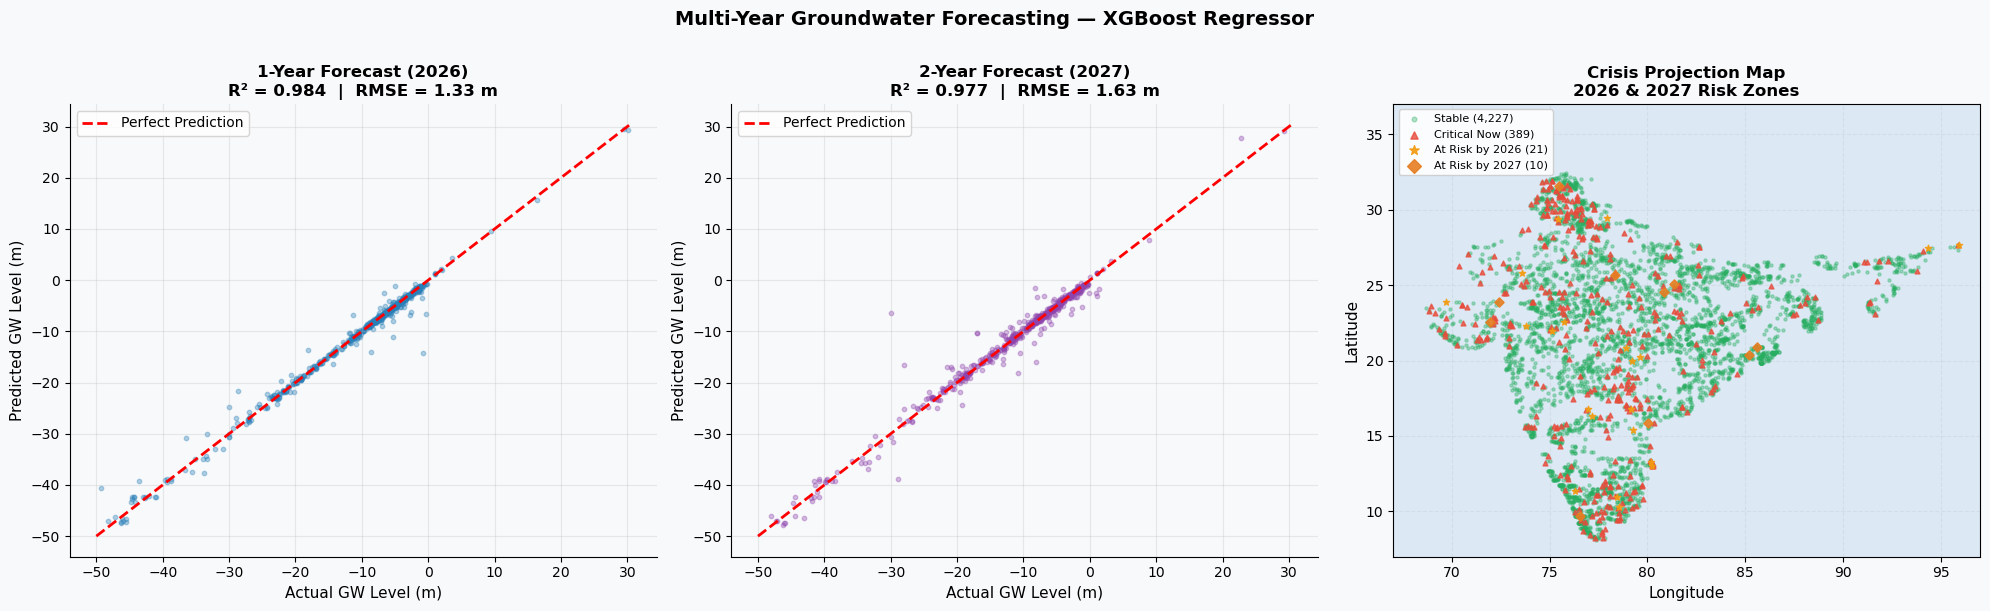

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#f8f9fa')

# ── Left: Actual vs Predicted (1yr) ──────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#f8f9fa')
idx = np.random.choice(len(yte_1), size=min(600,len(yte_1)), replace=False)
ax.scatter(yte_1.values[idx], ypred_1[idx], alpha=0.35, s=10, color='#2980b9')
mn=min(yte_1.min(),ypred_1.min()); mx=max(yte_1.max(),ypred_1.max())
ax.plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect Prediction')
ax.set_xlabel('Actual GW Level (m)',fontsize=11)
ax.set_ylabel('Predicted GW Level (m)',fontsize=11)
ax.set_title(f'1-Year Forecast (2026)\nR² = {r2_1:.3f}  |  RMSE = {rmse_1:.2f} m',
             fontsize=12,fontweight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.25)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Middle: Actual vs Predicted (2yr) ────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor('#f8f9fa')
idx2 = np.random.choice(len(yte_2), size=min(600,len(yte_2)), replace=False)
ax2.scatter(yte_2.values[idx2], ypred_2[idx2], alpha=0.35, s=10, color='#8e44ad')
mn2=min(yte_2.min(),ypred_2.min()); mx2=max(yte_2.max(),ypred_2.max())
ax2.plot([mn2,mx2],[mn2,mx2],'r--',lw=2,label='Perfect Prediction')
ax2.set_xlabel('Actual GW Level (m)',fontsize=11)
ax2.set_ylabel('Predicted GW Level (m)',fontsize=11)
ax2.set_title(f'2-Year Forecast (2027)\nR² = {r2_2:.3f}  |  RMSE = {rmse_2:.2f} m',
             fontsize=12,fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True,alpha=0.25)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# ── Right: Risk Projection Map ────────────────────────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#dce9f5')
stable  = latest[~latest['now_critical'] & ~latest['newly_at_risk_2026'] & ~latest['newly_at_risk_2027']]
current = latest[latest['now_critical']]
risk26  = latest[latest['newly_at_risk_2026']]
risk27  = latest[latest['newly_at_risk_2027']]

ax3.scatter(stable['longitude'],  stable['latitude'],
            c='#27ae60',s=5,alpha=0.35,label=f'Stable ({len(stable):,})')
ax3.scatter(current['longitude'], current['latitude'],
            c='#e74c3c',s=12,alpha=0.8,label=f'Critical Now ({len(current):,})',marker='^')
ax3.scatter(risk26['longitude'],  risk26['latitude'],
            c='#f39c12',s=22,alpha=0.9,label=f'At Risk by 2026 ({len(risk26):,})',marker='*',zorder=5)
ax3.scatter(risk27['longitude'],  risk27['latitude'],
            c='#e67e22',s=22,alpha=0.9,label=f'At Risk by 2027 ({len(risk27):,})',marker='D',zorder=4)
ax3.set_xlim(67,97); ax3.set_ylim(7,37)
ax3.set_xlabel('Longitude',fontsize=11); ax3.set_ylabel('Latitude',fontsize=11)
ax3.set_title('Crisis Projection Map\n2026 & 2027 Risk Zones',fontsize=12,fontweight='bold')
ax3.legend(fontsize=8,markerscale=1.5,loc='upper left',framealpha=0.9)
ax3.grid(True,alpha=0.2,linestyle='--')

plt.suptitle('Multi-Year Groundwater Forecasting — XGBoost Regressor',
             fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

## 30-Year National Trend

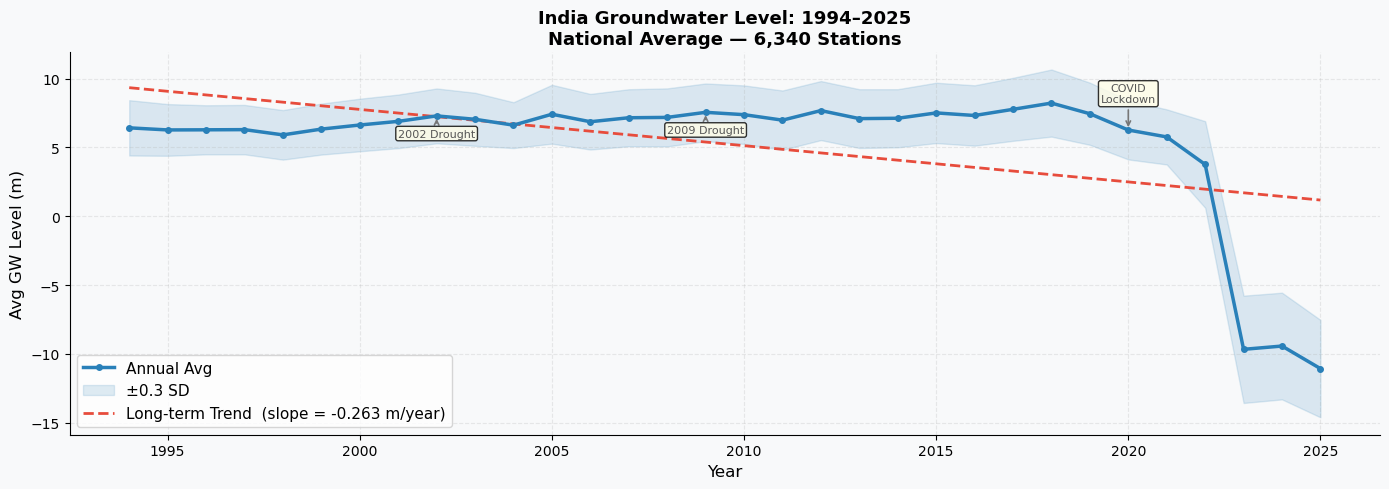

Trend: declining at 0.263 m/year


In [13]:
yearly = df.groupby('year')['target'].agg(['mean','std']).reset_index()
z = np.polyfit(yearly['year'], yearly['mean'], 1)
p_fn = np.poly1d(z)

fig,ax = plt.subplots(figsize=(14,5))
fig.patch.set_facecolor('#f8f9fa'); ax.set_facecolor('#f8f9fa')
ax.plot(yearly['year'],yearly['mean'],color='#2980b9',lw=2.5,marker='o',ms=4,zorder=3,label='Annual Avg')
ax.fill_between(yearly['year'],
                yearly['mean']-yearly['std']*0.3,
                yearly['mean']+yearly['std']*0.3,
                alpha=0.15,color='#2980b9',label='±0.3 SD')
ax.plot(yearly['year'],p_fn(yearly['year']),'--',color='#e74c3c',lw=2,
        label=f'Long-term Trend  (slope = {z[0]:+.3f} m/year)')

for yr,lbl,dy in [(2002,'2002 Drought',-1.5),(2009,'2009 Drought',-1.5),(2020,'COVID\nLockdown',2)]:
    if yr in yearly['year'].values:
        val = yearly[yearly['year']==yr]['mean'].values[0]
        ax.annotate(lbl,xy=(yr,val),xytext=(yr,val+dy),
                    arrowprops=dict(arrowstyle='->',color='#777',lw=1.2),
                    fontsize=8,color='#555',ha='center',
                    bbox=dict(boxstyle='round,pad=0.2',facecolor='#fffde7',alpha=0.8))

ax.set_xlabel('Year',fontsize=12); ax.set_ylabel('Avg GW Level (m)',fontsize=12)
ax.set_title(f'India Groundwater Level: 1994–2025\n'
             f'National Average — {df["station_id"].nunique():,} Stations',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=11); ax.grid(True,alpha=0.25,linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Trend: {'declining' if z[0]<0 else 'recovering'} at {abs(z[0]):.3f} m/year")

## Final Results Summary

In [14]:
print("="*65)
print("  INDIA GROUNDWATER EARLY WARNING SYSTEM — RESULTS")
print("="*65)
print(f"  Data      : India WRIS, Govt. of India")
print(f"  Stations  : {station['station_id'].nunique():,}  |  Records: {len(df):,}  |  1994–2025")
print()
print(f"  [1] Isolation Forest")
print(f"      Anomalous stations : {station['is_anomaly'].sum()} ({station['is_anomaly'].mean()*100:.1f}%)")
print()
print(f"  [2] Crisis Classification")
print(f"      XGBoost  : {xgb_acc*100:.2f}%  |  Random Forest : {rf_acc*100:.2f}%")
print()
print(f"  [3] Multi-Year Forecasting (Chronological Split)")
print(f"      2026 → R²={r2_1:.3f}  RMSE={rmse_1:.2f}m  MAE={mae_1:.2f}m")
print(f"      2027 → R²={r2_2:.3f}  RMSE={rmse_2:.2f}m  MAE={mae_2:.2f}m")
print(f"      Stations entering critical zone by 2026 : {latest['newly_at_risk_2026'].sum()}")
print(f"      Additionally at risk by 2027            : {latest['newly_at_risk_2027'].sum()}")
print()

  INDIA GROUNDWATER EARLY WARNING SYSTEM — RESULTS
  Data      : India WRIS, Govt. of India
  Stations  : 6,340  |  Records: 406,783  |  1994–2025

  [1] Isolation Forest
      Anomalous stations : 951 (15.0%)

  [2] Crisis Classification
      XGBoost  : 62.22%  |  Random Forest : 49.84%

  [3] Multi-Year Forecasting (Chronological Split)
      2026 → R²=0.984  RMSE=1.33m  MAE=0.52m
      2027 → R²=0.977  RMSE=1.63m  MAE=0.67m
      Stations entering critical zone by 2026 : 21
      Additionally at risk by 2027            : 10

